# Modelo 1 — Random Forest com histórico temporal

In [211]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [212]:
vendas = pd.read_csv('vendas_urban_style.csv', sep=';')
vendas.head()

,id_venda,data_venda,cliente_id,produto_id,canal_venda,quantidade,preco_unitario,valor_bruto,desconto_percentual,valor_desconto,valor_liquido,custo_total,lucro_bruto,margem_percentual,status,competencia
0,VEN000001,2023-08-24,CLI098,PROD001,Loja Física,1,67.4,67.4,0.0,0.0,67.4,28.78,38.62,57.3,Concluída,2023-08
1,VEN000002,2023-08-22,CLI063,PROD001,Loja Física,2,67.4,134.8,0.0,0.0,134.8,57.56,77.24,57.3,Concluída,2023-08
2,VEN000003,2023-08-18,CLI074,PROD001,E-commerce,1,67.4,67.4,0.0,0.0,67.4,28.78,38.62,57.3,Concluída,2023-08
3,VEN000004,2023-08-31,CLI034,PROD001,Loja Física,1,67.4,67.4,0.0,0.0,67.4,28.78,38.62,57.3,Concluída,2023-08
4,VEN000005,2023-08-06,CLI081,PROD001,Loja Física,2,67.4,134.8,0.0,0.0,134.8,57.56,77.24,57.3,Concluída,2023-08


In [213]:
# Conhecendo os dados
vendas.shape

(30730, 16)

In [214]:
# Nome das colunas
vendas.columns

Index(['id_venda', 'data_venda', 'cliente_id', 'produto_id', 'canal_venda',
       'quantidade', 'preco_unitario', 'valor_bruto', 'desconto_percentual',
       'valor_desconto', 'valor_liquido', 'custo_total', 'lucro_bruto',
       'margem_percentual', 'status', 'competencia'],
      dtype='str')

In [215]:
# Verificando os tipos de dados das colunas
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 30730 entries, 0 to 30729
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_venda             30730 non-null  str    
 1   data_venda           30730 non-null  str    
 2   cliente_id           30730 non-null  str    
 3   produto_id           30730 non-null  str    
 4   canal_venda          30730 non-null  str    
 5   quantidade           30730 non-null  int64  
 6   preco_unitario       30730 non-null  float64
 7   valor_bruto          30730 non-null  float64
 8   desconto_percentual  30730 non-null  float64
 9   valor_desconto       30730 non-null  float64
 10  valor_liquido        30730 non-null  float64
 11  custo_total          30730 non-null  float64
 12  lucro_bruto          30730 non-null  float64
 13  margem_percentual    30730 non-null  float64
 14  status               30730 non-null  str    
 15  competencia          30730 non-null  str    
dt

In [216]:
# Procurando dados ausentes
vendas.isnull().sum()

id_venda               0
data_venda             0
cliente_id             0
produto_id             0
canal_venda            0
quantidade             0
preco_unitario         0
valor_bruto            0
desconto_percentual    0
valor_desconto         0
valor_liquido          0
custo_total            0
lucro_bruto            0
margem_percentual      0
status                 0
competencia            0
dtype: int64

In [217]:
# Convertendo a coluna "data_venda" para o tipo datetime
vendas["data_venda"] = pd.to_datetime(vendas["data_venda"])
vendas.info()

<class 'pandas.DataFrame'>
RangeIndex: 30730 entries, 0 to 30729
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id_venda             30730 non-null  str           
 1   data_venda           30730 non-null  datetime64[us]
 2   cliente_id           30730 non-null  str           
 3   produto_id           30730 non-null  str           
 4   canal_venda          30730 non-null  str           
 5   quantidade           30730 non-null  int64         
 6   preco_unitario       30730 non-null  float64       
 7   valor_bruto          30730 non-null  float64       
 8   desconto_percentual  30730 non-null  float64       
 9   valor_desconto       30730 non-null  float64       
 10  valor_liquido        30730 non-null  float64       
 11  custo_total          30730 non-null  float64       
 12  lucro_bruto          30730 non-null  float64       
 13  margem_percentual    30730 non-null  float

In [218]:
# Verificando o periodo da base
print(vendas["data_venda"].min())

print(vendas["data_venda"].max())

2023-08-01 00:00:00
2026-07-31 00:00:00


In [219]:
# Verificando a quantidade de vendas por status
vendas["status"].value_counts()

status
Concluída    30730
Name: count, dtype: int64

In [220]:
# Filtrando apenas as vendas concluídas
vendas_concluidas = vendas[
    vendas["status"] == "Concluída"
].copy()
vendas_concluidas.shape

(30730, 16)

In [221]:
# Adicionando uma coluna com o período (ano-mês) da venda
vendas_concluidas["periodo"] = (vendas_concluidas["data_venda"].dt.to_period("M"))

vendas_concluidas[["data_venda", "periodo"]].head()

vendas_concluidas.head()

,id_venda,data_venda,cliente_id,produto_id,canal_venda,quantidade,preco_unitario,valor_bruto,desconto_percentual,valor_desconto,valor_liquido,custo_total,lucro_bruto,margem_percentual,status,competencia,periodo
0,VEN000001,2023-08-24,CLI098,PROD001,Loja Física,1,67.4,67.4,0.0,0.0,67.4,28.78,38.62,57.3,Concluída,2023-08,2023-08
1,VEN000002,2023-08-22,CLI063,PROD001,Loja Física,2,67.4,134.8,0.0,0.0,134.8,57.56,77.24,57.3,Concluída,2023-08,2023-08
2,VEN000003,2023-08-18,CLI074,PROD001,E-commerce,1,67.4,67.4,0.0,0.0,67.4,28.78,38.62,57.3,Concluída,2023-08,2023-08
3,VEN000004,2023-08-31,CLI034,PROD001,Loja Física,1,67.4,67.4,0.0,0.0,67.4,28.78,38.62,57.3,Concluída,2023-08,2023-08
4,VEN000005,2023-08-06,CLI081,PROD001,Loja Física,2,67.4,134.8,0.0,0.0,134.8,57.56,77.24,57.3,Concluída,2023-08,2023-08


In [222]:
# Agrupando as vendas por produto e período, somando a quantidade vendida
vendas_mensais = (
    vendas_concluidas
    .groupby(
        ["produto_id", "periodo"]
    )
    .agg(
        quantidade_vendida=("quantidade", "sum")
    )
    .reset_index()
)
vendas_mensais.head(20)

,produto_id,periodo,quantidade_vendida
0,PROD001,2023-08,15
1,PROD001,2023-09,19
2,PROD001,2023-10,19
3,PROD001,2023-11,26
4,PROD001,2023-12,32
5,PROD001,2024-01,25
6,PROD001,2024-02,26
7,PROD001,2024-03,21
8,PROD001,2024-04,17
9,PROD001,2024-05,15


In [223]:
# Verificando a quantidade de produtos únicos na base
produtos = vendas[
    "produto_id"
].unique()
len(produtos)

80

In [224]:
# Criando um período de tempo para o eixo x do gráfico
periodos = pd.period_range(
    start="2023-08",
    end="2026-07",
    freq="M"
)
len(periodos)

36

In [225]:
# Criando uma grade completa de produtos e períodos
grade_completa = (
    pd.MultiIndex.from_product(
        [produtos, periodos],
        names=[
            "produto_id",
            "periodo"
        ]
    )
    .to_frame(index=False)
)
grade_completa.shape

(2880, 2)

In [226]:
# Mesclando a grade completa com as vendas mensais para preencher os períodos sem vendas
vendas_mensais = (
    grade_completa
    .merge(
        vendas_mensais,
        on=[
            "produto_id",
            "periodo"
        ],
        how="left"
    )
)

In [227]:
# Preenchendo os valores ausentes de quantidade vendida com 0
vendas_mensais[
    "quantidade_vendida"
] = (
    vendas_mensais[
        "quantidade_vendida"
    ]
    .fillna(0)
)
vendas_mensais.shape

(2880, 3)

In [228]:
# Ordenando os dados por produto e período
vendas_mensais = (
    vendas_mensais
    .sort_values(
        [
            "produto_id",
            "periodo"
        ]
    )
    .reset_index(drop=True)
)

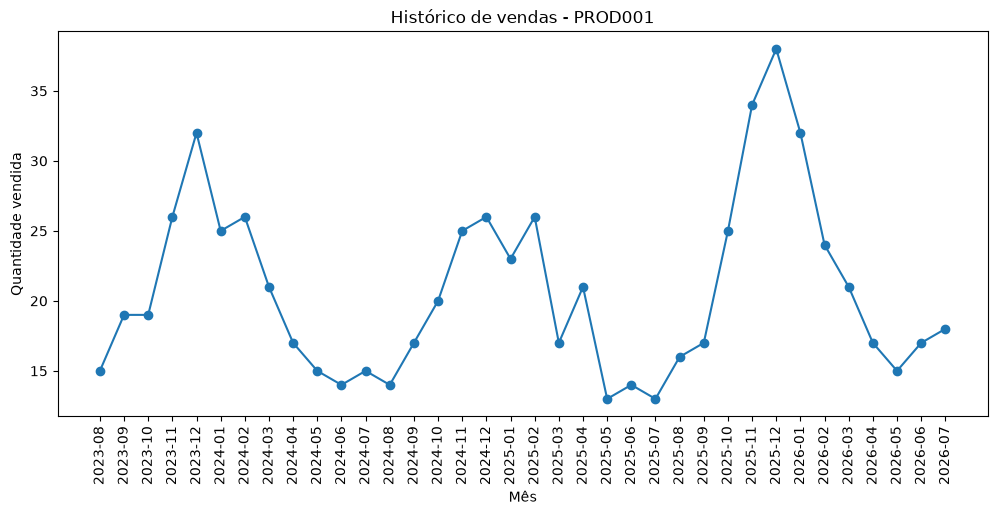

In [229]:
# Visualizando o histórico de vendas de um produto específico
produto_exemplo = "PROD001"

historico_produto = vendas_mensais[
    vendas_mensais["produto_id"]
    == produto_exemplo
]

plt.figure(figsize=(12, 5))

plt.plot(
    historico_produto[
        "periodo"
    ].astype(str),
    historico_produto[
        "quantidade_vendida"
    ],
    marker="o"
)

plt.xticks(rotation=90)

plt.xlabel("Mês")
plt.ylabel("Quantidade vendida")

plt.title(
    f"Histórico de vendas - {produto_exemplo}"
)

plt.show()

In [230]:
# Criando uma coluna para o mês
vendas_mensais["mes"] = (vendas_mensais["periodo"].dt.month)

vendas_mensais[["periodo","mes"]].head()

,periodo,mes
0,2023-08,8
1,2023-09,9
2,2023-10,10
3,2023-11,11
4,2023-12,12


In [231]:
# Criando uma coluna com a quantidade vendida no mês anterior para cada produto
vendas_mensais["venda_mes_anterior"] = (vendas_mensais.groupby("produto_id")["quantidade_vendida"].shift(1))

In [232]:
# Criando uma coluna com a quantidade vendida há DOIS meses para cada produto
vendas_mensais[
    "venda_2_meses"
] = (
    vendas_mensais
    .groupby(
        "produto_id"
    )[
        "quantidade_vendida"
    ]
    .shift(2)
)

In [233]:
# Criando uma coluna com a quantidade vendida há TRÊS meses para cada produto
vendas_mensais[
    "venda_3_meses"
] = (
    vendas_mensais
    .groupby(
        "produto_id"
    )[
        "quantidade_vendida"
    ]
    .shift(3)
)

In [234]:
# Visualizando as colunas criadas para um produto específico
vendas_mensais[
    vendas_mensais["produto_id"]
    == "PROD001"
][
    [
        "periodo",
        "quantidade_vendida",
        "venda_mes_anterior",
        "venda_2_meses",
        "venda_3_meses"
    ]
].head(10)

,periodo,quantidade_vendida,venda_mes_anterior,venda_2_meses,venda_3_meses
0,2023-08,15,NaN,NaN,NaN
1,2023-09,19,15.0,NaN,NaN
2,2023-10,19,19.0,15.0,NaN
3,2023-11,26,19.0,19.0,15.0
4,2023-12,32,26.0,19.0,19.0
5,2024-01,25,32.0,26.0,19.0
6,2024-02,26,25.0,32.0,26.0
7,2024-03,21,26.0,25.0,32.0
8,2024-04,17,21.0,26.0,25.0
9,2024-05,15,17.0,21.0,26.0


In [235]:
# Criando uma coluna com a quantidade vendida há TRÊS meses para cada produto
vendas_mensais[
    "media_3_meses"
] = (
    vendas_mensais
    .groupby(
        "produto_id"
    )[
        "quantidade_vendida"
    ]
    .transform(
        lambda x:
        x.shift(1) # impede que o modelo use informações do próprio mês para calcular a média
        .rolling(3)
        .mean()
    )
)

In [236]:
# Criando uma coluna com a tendência de vendas para cada produto
vendas_mensais[
    "tendencia"
] = (
    vendas_mensais[
        "venda_mes_anterior"
    ]
    -
    vendas_mensais[
        "venda_2_meses"
    ]
)

In [237]:
dados_ml = vendas_mensais.dropna(
    subset=[
        "venda_mes_anterior",
        "venda_2_meses",
        "venda_3_meses",
        "media_3_meses"
    ]
).copy()
dados_ml.shape

(2640, 9)

In [238]:
# Definindo as features e o target para o modelo de machine learning
features = [
    "mes",
    "venda_mes_anterior",
    "venda_2_meses",
    "venda_3_meses",
    "media_3_meses",
    "tendencia"
]

target = "quantidade_vendida"

In [239]:
# Separando os dados em treino e teste
treino = dados_ml[
    dados_ml["periodo"]
    <= pd.Period(
        "2026-04",
        freq="M"
    )
].copy()

teste = dados_ml[
    dados_ml["periodo"]
    > pd.Period(
        "2026-04",
        freq="M"
    )
].copy()

In [240]:
# Verificando o período dos dados de treino e teste
print(
    treino["periodo"].min(),
    treino["periodo"].max()
)

print(
    teste["periodo"].min(),
    teste["periodo"].max()
)

2023-11 2026-04
2026-05 2026-07


In [241]:
# Separando as features e o target para treino e teste
X_train = treino[features]
y_train = treino[target]

X_test = teste[features]
y_test = teste[target]

print(
    "X_train:",
    X_train.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_train:",
    y_train.shape
)

print(
    "y_test:",
    y_test.shape
)

X_train: (2400, 6)
X_test: (240, 6)
y_train: (2400,)
y_test: (240,)


In [242]:
# Criando uma previsão baseline utilizando a venda do mês anterior
previsao_baseline = (
    X_test[
        "venda_mes_anterior"
    ]
)

In [243]:
# Calculando o erro absoluto médio (MAE) da previsão baseline
from sklearn.metrics import (mean_absolute_error)

mae_baseline = (mean_absolute_error(y_test,previsao_baseline))

print(
    "MAE Baseline:",
    round(
        mae_baseline,
        2
    )
)

MAE Baseline: 2.51


In [244]:

from sklearn.ensemble import (
    RandomForestRegressor
)
modelo = RandomForestRegressor(
    n_estimators=250,
    max_depth=10,
    random_state=42
)

In [245]:
# Treinando o modelo de machine learning
modelo.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [246]:
# Fazendo previsões com o modelo treinado
previsoes = modelo.predict(
    X_test
)

In [247]:
# Calculando o erro absoluto médio (MAE) do modelo treinado
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [248]:
# Calculando o erro absoluto médio (MAE) do modelo treinado
mae = mean_absolute_error(
    y_test,
    previsoes
)

In [249]:
# Calculando o erro quadrático médio (RMSE) do modelo treinado
rmse = (
    mean_squared_error(
        y_test,
        previsoes
    ) ** 0.5
)

In [250]:
# Calculando o R² do modelo treinado
r2 = r2_score(
    y_test,
    previsoes
)

In [251]:
# Imprimindo os resultados das métricas de avaliação do modelo
print(
    "MAE Baseline:",
    round(mae_baseline, 2)
)

print(
    "MAE Random Forest:",
    round(mae, 2)
)

print(
    "RMSE Random Forest:",
    round(rmse, 2)
)

print(
    "R² Random Forest:",
    round(r2, 2)
)

MAE Baseline: 2.51
MAE Random Forest: 2.37
RMSE Random Forest: 3.45
R² Random Forest: 0.75


In [252]:
print(
    dados_ml["quantidade_vendida"].describe()
)

count    2640.000000
mean       16.798864
std         7.476227
min         3.000000
25%        12.000000
50%        15.000000
75%        21.000000
max        55.000000
Name: quantidade_vendida, dtype: float64


In [253]:
# Calculando o erro relativo aproximado do modelo treinado
media_demanda = y_test.mean()

erro_relativo = (
    mae / media_demanda
) * 100

print(
    "Demanda média:",
    round(media_demanda, 2)
)

print(
    "MAE:",
    round(mae, 2)
)

print(
    "Erro relativo aproximado:",
    round(erro_relativo, 2),
    "%"
)

Demanda média: 16.18
MAE: 2.37
Erro relativo aproximado: 14.65 %


In [254]:
# Criando um DataFrame com os resultados das previsões
resultado = teste[
    [
        "produto_id",
        "periodo",
        "quantidade_vendida"
    ]
].copy()
resultado["previsao"] = previsoes

In [255]:
# 
resultado["erro"] = (
    resultado["quantidade_vendida"]
    - resultado["previsao"]
)

In [256]:
# Calculando o erro absoluto do modelo treinado
resultado["erro_absoluto"] = (
    resultado["erro"].abs()
)

In [257]:
resultado.head(10)

,produto_id,periodo,quantidade_vendida,previsao,erro,erro_absoluto
33,PROD001,2026-05,15,16.980795,-1.980795,1.980795
34,PROD001,2026-06,17,13.947564,3.052436,3.052436
35,PROD001,2026-07,18,16.714304,1.285696,1.285696
69,PROD002,2026-05,13,10.624958,2.375042,2.375042
70,PROD002,2026-06,12,12.976454,-0.976454,0.976454
71,PROD002,2026-07,12,11.707131,0.292869,0.292869
105,PROD003,2026-05,13,14.214176,-1.214176,1.214176
106,PROD003,2026-06,11,12.937144,-1.937144,1.937144
107,PROD003,2026-07,9,11.743030,-2.743030,2.743030
141,PROD004,2026-05,24,22.859243,1.140757,1.140757


In [258]:
#  Maiores erros
maiores_erros = (
    resultado
    .sort_values(
        "erro_absoluto",
        ascending=False
    )
    .head(10)
)
maiores_erros

,produto_id,periodo,quantidade_vendida,previsao,erro,erro_absoluto
1619,PROD045,2026-07,41,26.390889,14.609111,14.609111
2230,PROD062,2026-06,42,27.724454,14.275546,14.275546
1617,PROD045,2026-05,39,24.976554,14.023446,14.023446
934,PROD026,2026-06,30,16.321802,13.678198,13.678198
142,PROD004,2026-06,40,26.949871,13.050129,13.050129
143,PROD004,2026-07,39,27.555591,11.444409,11.444409
645,PROD018,2026-05,28,16.862045,11.137955,11.137955
2229,PROD062,2026-05,35,25.351320,9.648680,9.648680
611,PROD017,2026-07,25,16.194163,8.805837,8.805837
1113,PROD031,2026-05,23,15.181488,7.818512,7.818512


In [259]:
#  Erros por produto
erro_por_produto = (
    resultado
    .groupby("produto_id")
    ["erro_absoluto"]
    .mean()
    .sort_values(
        ascending=False
    )
)
erro_por_produto.head(10)

produto_id
PROD045    10.801363
PROD062     9.187534
PROD004     8.545098
PROD026     5.031241
PROD044     4.746443
PROD042     4.694332
PROD009     4.477115
PROD031     4.451494
PROD056     4.198763
PROD018     3.841412
Name: erro_absoluto, dtype: float64

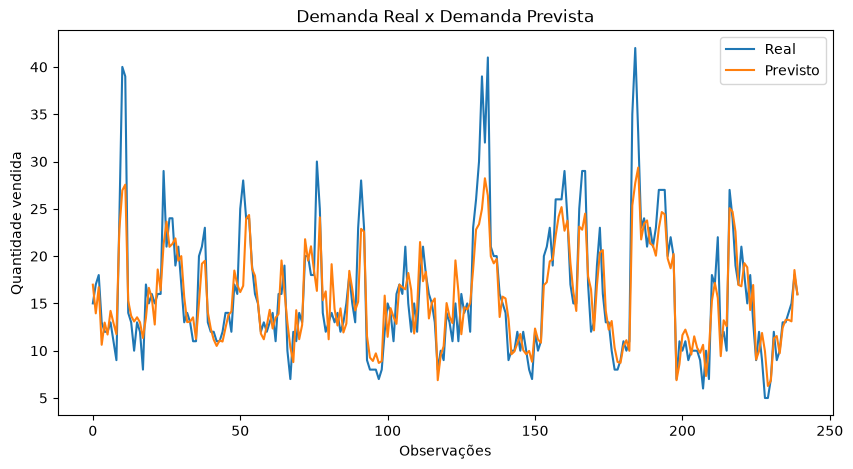

In [260]:
# Visualizando a demanda real x demanda prevista
plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Real"
)

plt.plot(
    previsoes,
    label="Previsto"
)

plt.xlabel("Observações")
plt.ylabel("Quantidade vendida")

plt.title(
    "Demanda Real x Demanda Prevista"
)

plt.legend()

plt.show()

In [261]:
# Importância das variáveis
importancias = pd.DataFrame({
    "variavel": features,
    "importancia": modelo.feature_importances_
})

importancias = (
    importancias
    .sort_values(
        "importancia",
        ascending=False
    )
)
importancias

,variavel,importancia
1,venda_mes_anterior,0.718540
0,mes,0.120445
4,media_3_meses,0.063170
3,venda_3_meses,0.042233
2,venda_2_meses,0.031328
5,tendencia,0.024284


# MODELO 2 - Random Forest com características dos produtos

In [262]:
produtos_df = pd.read_csv('produtos_urban_style.csv', sep=';')
produtos_df.head()

,id,sku,nome,categoria,cor,tamanho,fornecedor_id,custo_base,preco_base,estoque_minimo,demanda_base_mensal,perfil_sazonal,tendencia_mensal,popularidade,ativo
0,PROD001,US-1001,Básica Branca Preto G,Camisetas,Preto,G,FOR017,28.78,67.40,11,17,verao,0.0053,1.057,True
1,PROD002,US-1002,Wide Leg Cinza M,Calças,Cinza,M,FOR009,56.44,135.07,8,10,estavel,0.0025,1.124,True
2,PROD003,US-1003,Canelado Rosa PP,Vestidos,Rosa,PP,FOR017,83.03,176.66,10,15,verao,-0.0015,1.036,True
3,PROD004,US-1004,Puffer Preto M,Jaquetas,Preto,M,FOR009,131.07,259.98,9,13,inverno,0.0098,1.200,True
4,PROD005,US-1005,Jeans Azul P,Bermudas,Azul,P,FOR009,46.90,93.61,11,16,verao,-0.0006,1.038,True


In [263]:
produtos_df.columns

Index(['id', 'sku', 'nome', 'categoria', 'cor', 'tamanho', 'fornecedor_id',
       'custo_base', 'preco_base', 'estoque_minimo', 'demanda_base_mensal',
       'perfil_sazonal', 'tendencia_mensal', 'popularidade', 'ativo'],
      dtype='str')

In [264]:
# Selecionando 3 colunas do DataFrame de produtos
caracteristicas_produtos = produtos_df[
    [
        "id",
        "categoria",
        "preco_base"
    ]
].copy()

In [265]:
# Renomeando a coluna "id" para "produto_id" no DataFrame de características dos produtos
caracteristicas_produtos = (
    caracteristicas_produtos
    .rename(
        columns={
            "id": "produto_id"
        }
    )
)
caracteristicas_produtos.head()

,produto_id,categoria,preco_base
0,PROD001,Camisetas,67.40
1,PROD002,Calças,135.07
2,PROD003,Vestidos,176.66
3,PROD004,Jaquetas,259.98
4,PROD005,Bermudas,93.61


In [266]:
# Mesclando o DataFrame de vendas com o DataFrame de características dos produtos
dados_ml_2 = dados_ml.merge(
    caracteristicas_produtos,
    on="produto_id",
    how="left"
)

dados_ml_2[
    [
        "produto_id",
        "periodo",
        "quantidade_vendida",
        "categoria",
        "preco_base"
    ]
].head()

,produto_id,periodo,quantidade_vendida,categoria,preco_base
0,PROD001,2023-11,26,Camisetas,67.4
1,PROD001,2023-12,32,Camisetas,67.4
2,PROD001,2024-01,25,Camisetas,67.4
3,PROD001,2024-02,26,Camisetas,67.4
4,PROD001,2024-03,21,Camisetas,67.4


In [267]:
# Criando variáveis dummies para a coluna "categoria"
dados_ml_2 = pd.get_dummies(
    dados_ml_2,
    columns=["categoria"],
    dtype=int
)
dados_ml_2.columns

Index(['produto_id', 'periodo', 'quantidade_vendida', 'mes',
       'venda_mes_anterior', 'venda_2_meses', 'venda_3_meses', 'media_3_meses',
       'tendencia', 'preco_base', 'categoria_Acessórios', 'categoria_Bermudas',
       'categoria_Blusas', 'categoria_Calças', 'categoria_Camisas',
       'categoria_Camisetas', 'categoria_Jaquetas', 'categoria_Saias',
       'categoria_Vestidos'],
      dtype='str')

In [268]:
# Definindo as features e o target para o modelo de machine learning
features_modelo_2 = [
    "mes",
    "venda_mes_anterior",
    "venda_2_meses",
    "venda_3_meses",
    "media_3_meses",
    "tendencia",
    "preco_base"
]

In [269]:
# Adicionando as colunas dummies de categoria às features do modelo
features_modelo_2 = [
    "mes",
    "venda_mes_anterior",
    "venda_2_meses",
    "venda_3_meses",
    "media_3_meses",
    "tendencia",
    "preco_base"
]

colunas_categoria = [
    coluna
    for coluna in dados_ml_2.columns
    if coluna.startswith("categoria_")
]

features_modelo_2 = (
    features_modelo_2
    + colunas_categoria
)
features_modelo_2

['mes',
 'venda_mes_anterior',
 'venda_2_meses',
 'venda_3_meses',
 'media_3_meses',
 'tendencia',
 'preco_base',
 'categoria_Acessórios',
 'categoria_Bermudas',
 'categoria_Blusas',
 'categoria_Calças',
 'categoria_Camisas',
 'categoria_Camisetas',
 'categoria_Jaquetas',
 'categoria_Saias',
 'categoria_Vestidos']

In [270]:
# Definindo o número de features para o modelo
len(features_modelo_2)


16

In [271]:
# Verificando se há features duplicadas na lista de features do modelo
len(features_modelo_2) == len(set(features_modelo_2))

True

In [272]:
# Separando os dados em treino e teste
treino_2 = dados_ml_2[
    dados_ml_2["periodo"]
    <= pd.Period("2026-04", freq="M")
].copy()

teste_2 = dados_ml_2[
    dados_ml_2["periodo"]
    > pd.Period("2026-04", freq="M")
].copy()

print(
    "Treino:",
    treino_2["periodo"].min(),
    "até",
    treino_2["periodo"].max()
)

print(
    "Teste:",
    teste_2["periodo"].min(),
    "até",
    teste_2["periodo"].max()
)

Treino: 2023-11 até 2026-04
Teste: 2026-05 até 2026-07


In [273]:
# Separando as features e o target para treino e teste
X_train_2 = treino_2[
    features_modelo_2
]

y_train_2 = treino_2[
    "quantidade_vendida"
]

X_test_2 = teste_2[
    features_modelo_2
]

y_test_2 = teste_2[
    "quantidade_vendida"
]

print(
    "X_train_2:",
    X_train_2.shape
)

print(
    "X_test_2:",
    X_test_2.shape
)

print(
    "y_train_2:",
    y_train_2.shape
)

print(
    "y_test_2:",
    y_test_2.shape
)

X_train_2: (2400, 16)
X_test_2: (240, 16)
y_train_2: (2400,)
y_test_2: (240,)


In [274]:
# Criando uma previsão baseline utilizando a venda do mês anterior
modelo_2 = RandomForestRegressor(
    n_estimators=250,
    max_depth=10,
    random_state=42
)

In [275]:
# Treinando o modelo de machine learning
modelo_2.fit(
    X_train_2,
    y_train_2
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [276]:
previsoes_2 = modelo_2.predict(
    X_test_2
)

In [277]:
# Calculando o erro absoluto médio (MAE) do modelo treinado
mae_2 = mean_absolute_error(
    y_test_2,
    previsoes_2
)

rmse_2 = (
    mean_squared_error(
        y_test_2,
        previsoes_2
    ) ** 0.5
)

r2_2 = r2_score(
    y_test_2,
    previsoes_2
)

print(
    "MAE Modelo 2:",
    round(mae_2, 2)
)

print(
    "RMSE Modelo 2:",
    round(rmse_2, 2)
)

print(
    "R² Modelo 2:",
    round(r2_2, 2)
)

MAE Modelo 2: 2.29
RMSE Modelo 2: 3.38
R² Modelo 2: 0.76


In [278]:
# Comparando os resultados dos dois modelos
comparacao = pd.DataFrame({
    "Modelo": [
        "Modelo 1 - Histórico",
        "Modelo 2 - Histórico + Produto"
    ],
    "MAE": [
        mae,
        mae_2
    ],
    "RMSE": [
        rmse,
        rmse_2
    ],
    "R²": [
        r2,
        r2_2
    ]
})

comparacao

,Modelo,MAE,RMSE,R²
0,Modelo 1 - Histórico,2.369947,3.454126,0.748099
1,Modelo 2 - Histórico + Produto,2.287443,3.378610,0.758993


In [279]:
# Criando um DataFrame com os resultados das previsões do modelo 2
resultado_2 = teste_2[
    [
        "produto_id",
        "periodo",
        "quantidade_vendida"
    ]
].copy()

resultado_2["previsao"] = previsoes_2

resultado_2["erro"] = (
    resultado_2["quantidade_vendida"]
    - resultado_2["previsao"]
)

resultado_2["erro_absoluto"] = (
    resultado_2["erro"].abs()
)

In [280]:
# Calculando o erro absoluto médio (MAE) do modelo treinado
maiores_erros_2 = (
    resultado_2
    .sort_values(
        "erro_absoluto",
        ascending=False
    )
    .head(10)
)

maiores_erros_2

,produto_id,periodo,quantidade_vendida,previsao,erro,erro_absoluto
1484,PROD045,2026-07,41,25.261801,15.738199,15.738199
130,PROD004,2026-06,40,24.867135,15.132865,15.132865
856,PROD026,2026-06,30,16.753625,13.246375,13.246375
1482,PROD045,2026-05,39,26.102866,12.897134,12.897134
2044,PROD062,2026-06,42,29.277267,12.722733,12.722733
2043,PROD062,2026-05,35,24.106233,10.893767,10.893767
131,PROD004,2026-07,39,29.505481,9.494519,9.494519
560,PROD017,2026-07,25,16.390739,8.609261,8.609261
591,PROD018,2026-05,28,19.815551,8.184449,8.184449
1020,PROD031,2026-05,23,15.301180,7.698820,7.698820


In [281]:
# Calculando a importâncias das variáveis do modelo treinado
importancias_2 = pd.DataFrame({
    "variavel": features_modelo_2,
    "importancia": modelo_2.feature_importances_
})

importancias_2 = (
    importancias_2
    .sort_values(
        "importancia",
        ascending=False
    )
)

importancias_2.head(10)

,variavel,importancia
1,venda_mes_anterior,0.701748
0,mes,0.109912
4,media_3_meses,0.047988
6,preco_base,0.036443
3,venda_3_meses,0.024904
2,venda_2_meses,0.021626
5,tendencia,0.013119
7,categoria_Acessórios,0.010803
12,categoria_Camisetas,0.007498
10,categoria_Calças,0.005564


In [282]:
import joblib
joblib.dump(
    modelo_2,
    "modelo_demanda_duaxis.pkl"
)

['modelo_demanda_duaxis.pkl']

In [283]:
joblib.dump(
    features_modelo_2,
    "features_demanda_duaxis.pkl"
)

['features_demanda_duaxis.pkl']

In [284]:
import joblib
joblib.dump(
    modelo_2,
    "modelo_demanda_duaxis.pkl"
)

['modelo_demanda_duaxis.pkl']

In [285]:
modelo_carregado = joblib.load(
    "modelo_demanda_duaxis.pkl"
)

features_carregadas = joblib.load(
    "features_demanda_duaxis.pkl"
)

print(features_carregadas)

['mes', 'venda_mes_anterior', 'venda_2_meses', 'venda_3_meses', 'media_3_meses', 'tendencia', 'preco_base', 'categoria_Acessórios', 'categoria_Bermudas', 'categoria_Blusas', 'categoria_Calças', 'categoria_Camisas', 'categoria_Camisetas', 'categoria_Jaquetas', 'categoria_Saias', 'categoria_Vestidos']


In [286]:
len(features_carregadas)

16

In [287]:
teste_carregamento = X_test_2.head(5)
previsao_teste = modelo_carregado.predict(
    teste_carregamento
)
print(previsao_teste)

[17.27088936 14.59094458 16.80276174 10.89857014 13.00246918]


# MODELO FINAL - Treinamento com todo o histórico

In [288]:
# Separando as features e o target para treino e teste
X_final = dados_ml_2[
    features_modelo_2
]

y_final = dados_ml_2[
    "quantidade_vendida"
]
print(
    "X_final:",
    X_final.shape
)

print(
    "y_final:",
    y_final.shape
)

X_final: (2640, 16)
y_final: (2640,)


In [289]:
modelo_final = RandomForestRegressor(
    n_estimators=250,
    max_depth=10,
    random_state=42
)

In [290]:
modelo_final.fit(
    X_final,
    y_final
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",250
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of 

In [291]:
joblib.dump(
    modelo_final,
    "modelo_demanda_duaxis_final.pkl"
)

['modelo_demanda_duaxis_final.pkl']

In [292]:
joblib.dump(
    features_modelo_2,
    "features_demanda_duaxis_final.pkl"
)

['features_demanda_duaxis_final.pkl']

# PREVENDO AGOSTO/2026

In [293]:
ultimos_meses = vendas_mensais[
    vendas_mensais["periodo"].isin(
        [
            pd.Period("2026-05", freq="M"),
            pd.Period("2026-06", freq="M"),
            pd.Period("2026-07", freq="M")
        ]
    )
].copy()
ultimos_meses.head()

,produto_id,periodo,quantidade_vendida,mes,venda_mes_anterior,venda_2_meses,venda_3_meses,media_3_meses,tendencia
33,PROD001,2026-05,15,5,17.0,21.0,24.0,20.666667,-4.0
34,PROD001,2026-06,17,6,15.0,17.0,21.0,17.666667,-2.0
35,PROD001,2026-07,18,7,17.0,15.0,17.0,16.333333,2.0
69,PROD002,2026-05,13,5,10.0,11.0,12.0,11.000000,-1.0
70,PROD002,2026-06,12,6,13.0,10.0,11.0,11.333333,3.0


In [294]:
historico_recente = (
    ultimos_meses
    .pivot(
        index="produto_id",
        columns="periodo",
        values="quantidade_vendida"
    )
    .reset_index()
)
historico_recente.head()

periodo,produto_id,2026-05,2026-06,2026-07
0,PROD001,15,17,18
1,PROD002,13,12,12
2,PROD003,13,11,9
3,PROD004,24,40,39
4,PROD005,14,13,10


In [295]:
historico_recente = (
    historico_recente.rename(
        columns={
            pd.Period("2026-05", freq="M"):
                "venda_3_meses",

            pd.Period("2026-06", freq="M"):
                "venda_2_meses",

            pd.Period("2026-07", freq="M"):
                "venda_mes_anterior"
        }
    )
)
historico_recente.head()

periodo,produto_id,venda_3_meses,venda_2_meses,venda_mes_anterior
0,PROD001,15,17,18
1,PROD002,13,12,12
2,PROD003,13,11,9
3,PROD004,24,40,39
4,PROD005,14,13,10


In [296]:
historico_recente[
    "media_3_meses"
] = (
    historico_recente[
        [
            "venda_3_meses",
            "venda_2_meses",
            "venda_mes_anterior"
        ]
    ]
    .mean(axis=1)
)

In [297]:
historico_recente[
    "tendencia"
] = (
    historico_recente[
        "venda_mes_anterior"
    ]
    -
    historico_recente[
        "venda_2_meses"
    ]
)

In [298]:
historico_recente[
    "mes"
] = 8

In [299]:
previsao_agosto = (
    historico_recente
    .merge(
        caracteristicas_produtos,
        on="produto_id",
        how="left"
    )
)
previsao_agosto.head()

,produto_id,venda_3_meses,venda_2_meses,venda_mes_anterior,media_3_meses,tendencia,mes,categoria,preco_base
0,PROD001,15,17,18,16.666667,1,8,Camisetas,67.40
1,PROD002,13,12,12,12.333333,0,8,Calças,135.07
2,PROD003,13,11,9,11.000000,-2,8,Vestidos,176.66
3,PROD004,24,40,39,34.333333,-1,8,Jaquetas,259.98
4,PROD005,14,13,10,12.333333,-3,8,Bermudas,93.61


In [300]:
previsao_agosto = pd.get_dummies(
    previsao_agosto,
    columns=[
        "categoria"
    ],
    dtype=int
)
previsao_agosto.columns

Index(['produto_id', 'venda_3_meses', 'venda_2_meses', 'venda_mes_anterior',
       'media_3_meses', 'tendencia', 'mes', 'preco_base',
       'categoria_Acessórios', 'categoria_Bermudas', 'categoria_Blusas',
       'categoria_Calças', 'categoria_Camisas', 'categoria_Camisetas',
       'categoria_Jaquetas', 'categoria_Saias', 'categoria_Vestidos'],
      dtype='str')

In [301]:
X_agosto = previsao_agosto[
    features_modelo_2
]
X_agosto.shape

(80, 16)

In [302]:
demanda_agosto = (
    modelo_final.predict(
        X_agosto
    )
)

In [303]:
previsao_agosto[
    "demanda_prevista"
] = demanda_agosto

In [304]:
previsao_agosto[
    "demanda_prevista_arredondada"
] = (
    previsao_agosto[
        "demanda_prevista"
    ]
    .round()
    .astype(int)
)

In [305]:
previsao_agosto[
    [
        "produto_id",
        "demanda_prevista",
        "demanda_prevista_arredondada"
    ]
].head(20)

,produto_id,demanda_prevista,demanda_prevista_arredondada
0,PROD001,17.337911,17
1,PROD002,12.505879,13
2,PROD003,10.417290,10
3,PROD004,31.060792,31
4,PROD005,12.162876,12
5,PROD006,10.188791,10
6,PROD007,14.824718,15
7,PROD008,15.004231,15
8,PROD009,22.103310,22
9,PROD010,18.579200,19


# Integração da previsão com estoque e financeiro

In [306]:
estoque_df = pd.read_csv('estoque_urban_style.csv', sep=';')
estoque_df.head()

,produto_id,estoque_atual,estoque_minimo,consumo_medio_mensal,lead_time_dias,status
0,PROD001,25,11,20.75,15,Normal
1,PROD002,25,8,11.83,10,Normal
2,PROD003,26,10,15.61,15,Normal
3,PROD004,34,9,19.50,10,Normal
4,PROD005,29,11,17.17,10,Normal


In [307]:
recomendacao_compra = previsao_agosto.merge(
    estoque_df,
    on="produto_id",
    how="left"
)

In [308]:
recomendacao_compra[
    [
        "produto_id",
        "demanda_prevista_arredondada",
        "estoque_atual",
        "estoque_minimo",
        "lead_time_dias"
    ]
].head(20)

,produto_id,demanda_prevista_arredondada,estoque_atual,estoque_minimo,lead_time_dias
0,PROD001,17,25,11,15
1,PROD002,13,25,8,10
2,PROD003,10,26,10,15
3,PROD004,31,34,9,10
4,PROD005,12,29,11,10
5,PROD006,10,26,8,10
6,PROD007,15,24,9,5
7,PROD008,15,29,8,20
8,PROD009,22,29,14,15
9,PROD010,19,34,18,7


In [309]:
recomendacao_compra[
    "quantidade_recomendada"
] = (
    recomendacao_compra[
        "demanda_prevista_arredondada"
    ]
    +
    recomendacao_compra[
        "estoque_minimo"
    ]
    -
    recomendacao_compra[
        "estoque_atual"
    ]
)

In [310]:
# Garantindo que a quantidade recomendada não seja negativa
recomendacao_compra[
    "quantidade_recomendada"
] = (
    recomendacao_compra[
        "quantidade_recomendada"
    ]
    .clip(lower=0)
)

In [311]:
# Visualizando a recomendação de compra para os produtos
def classificar_reposicao(row):
    if row["quantidade_recomendada"] == 0:
        return "Estoque suficiente"

    if row["estoque_atual"] < row["estoque_minimo"]:
        return "Reposição urgente"

    return "Reposição recomendada"

In [312]:
# Classificando a necessidade de reposição
recomendacao_compra[
    "status_reposicao"
] = recomendacao_compra.apply(
    classificar_reposicao,
    axis=1
)

In [313]:
# Visualizando a recomendação de compra para os produtos
recomendacao_compra[
    [
        "produto_id",
        "demanda_prevista_arredondada",
        "estoque_atual",
        "estoque_minimo",
        "quantidade_recomendada",
        "status_reposicao"
    ]
].head(20)

,produto_id,demanda_prevista_arredondada,estoque_atual,estoque_minimo,quantidade_recomendada,status_reposicao
0,PROD001,17,25,11,3,Reposição recomendada
1,PROD002,13,25,8,0,Estoque suficiente
2,PROD003,10,26,10,0,Estoque suficiente
3,PROD004,31,34,9,6,Reposição recomendada
4,PROD005,12,29,11,0,Estoque suficiente
5,PROD006,10,26,8,0,Estoque suficiente
6,PROD007,15,24,9,0,Estoque suficiente
7,PROD008,15,29,8,0,Estoque suficiente
8,PROD009,22,29,14,7,Reposição recomendada
9,PROD010,19,34,18,3,Reposição recomendada


In [314]:
# Calculando a demanda diária prevista para cada produto
recomendacao_compra[
    "demanda_diaria_prevista"
] = (
    recomendacao_compra[
        "demanda_prevista"
    ]
    / 30
)

In [315]:
recomendacao_compra[
    "cobertura_estoque_dias"
] = (
    recomendacao_compra["estoque_atual"]
    /
    recomendacao_compra["demanda_diaria_prevista"]
)

In [316]:
# Calculando a demanda durante o lead time para cada produto
recomendacao_compra[
    "demanda_durante_lead_time"
] = (
    recomendacao_compra[
        "demanda_diaria_prevista"
    ]
    *
    recomendacao_compra[
        "lead_time_dias"
    ]
)

In [317]:
# Calculando o ponto de reposição para cada produto
recomendacao_compra[
    "ponto_reposicao"
] = (
    recomendacao_compra[
        "demanda_durante_lead_time"
    ]
    +
    recomendacao_compra[
        "estoque_minimo"
    ]
)

In [318]:
# Classificando o risco de ruptura de estoque para cada produto
def classificar_risco(row):
    if row["estoque_atual"] < row["estoque_minimo"]:
        return "Alto"

    if row["estoque_atual"] <= row["ponto_reposicao"]:
        return "Médio"

    return "Baixo"

In [319]:
# Classificando o risco de ruptura de estoque para cada produto
recomendacao_compra[
    "risco_ruptura"
] = recomendacao_compra.apply(
    classificar_risco,
    axis=1
)

In [320]:
# Visualizando a recomendação de compra para os produtos
recomendacao_compra[
    [
        "produto_id",
        "demanda_prevista_arredondada",
        "estoque_atual",
        "estoque_minimo",
        "lead_time_dias",
        "ponto_reposicao",
        "quantidade_recomendada",
        "risco_ruptura"
    ]
].head(20)

,produto_id,demanda_prevista_arredondada,estoque_atual,estoque_minimo,lead_time_dias,ponto_reposicao,quantidade_recomendada,risco_ruptura
0,PROD001,17,25,11,15,19.668956,3,Baixo
1,PROD002,13,25,8,10,12.168626,0,Baixo
2,PROD003,10,26,10,15,15.208645,0,Baixo
3,PROD004,31,34,9,10,19.353597,6,Baixo
4,PROD005,12,29,11,10,15.054292,0,Baixo
5,PROD006,10,26,8,10,11.396264,0,Baixo
6,PROD007,15,24,9,5,11.470786,0,Baixo
7,PROD008,15,29,8,20,18.002821,0,Baixo
8,PROD009,22,29,14,15,25.051655,7,Baixo
9,PROD010,19,34,18,7,22.335147,3,Baixo


In [321]:
# Criando um DataFrame com os custos dos produtos
custos_produtos = produtos_df[
    [
        "id",
        "custo_base"
    ]
].rename(
    columns={
        "id": "produto_id"
    }
)

In [322]:
# Mesclando o DataFrame de recomendação de compra com o DataFrame de custos dos produtos
recomendacao_compra = (
    recomendacao_compra
    .merge(
        custos_produtos,
        on="produto_id",
        how="left"
    )
)

In [323]:
# Calculando o impacto financeiro da recomendação de compra para cada produto
recomendacao_compra[
    "impacto_financeiro"
] = (
    recomendacao_compra[
        "quantidade_recomendada"
    ]
    *
    recomendacao_compra[
        "custo_base"
    ]
)

In [324]:
# Arredondando o impacto financeiro para 2 casas decimais
recomendacao_compra[
    "impacto_financeiro"
] = (
    recomendacao_compra[
        "impacto_financeiro"
    ]
    .round(2)
)

In [325]:
# Visualizando a recomendação de compra para os produtos
recomendacao_compra[
    [
        "produto_id",
        "demanda_prevista_arredondada",
        "estoque_atual",
        "quantidade_recomendada",
        "custo_base",
        "impacto_financeiro",
        "risco_ruptura"
    ]
].head(20)

,produto_id,demanda_prevista_arredondada,estoque_atual,quantidade_recomendada,custo_base,impacto_financeiro,risco_ruptura
0,PROD001,17,25,3,28.78,86.34,Baixo
1,PROD002,13,25,0,56.44,0.00,Baixo
2,PROD003,10,26,0,83.03,0.00,Baixo
3,PROD004,31,34,6,131.07,786.42,Baixo
4,PROD005,12,29,0,46.90,0.00,Baixo
5,PROD006,10,26,0,61.07,0.00,Baixo
6,PROD007,15,24,0,65.27,0.00,Baixo
7,PROD008,15,29,0,76.12,0.00,Baixo
8,PROD009,22,29,7,21.13,147.91,Baixo
9,PROD010,19,34,3,52.26,156.78,Baixo


In [326]:
def classificar_risco_ruptura(row):

    cobertura = row["cobertura_estoque_dias"]
    lead_time = row["lead_time_dias"]

    if cobertura <= lead_time:
        return "Alto"

    elif cobertura <= lead_time + 7:
        return "Médio"

    else:
        return "Baixo"

In [327]:
recomendacao_compra[
    "risco_ruptura"
] = recomendacao_compra.apply(
    classificar_risco_ruptura,
    axis=1
)

In [328]:
ordem_risco = {
    "Alto": 1,
    "Médio": 2,
    "Baixo": 3
}

recomendacao_compra[
    "ordem_risco"
] = recomendacao_compra[
    "risco_ruptura"
].map(ordem_risco)

In [329]:
produtos_criticos = (
    recomendacao_compra
    .sort_values(
        [
            "ordem_risco",
            "cobertura_estoque_dias"
        ],
        ascending=[
            True,
            True
        ]
    )
)

In [330]:
produtos_criticos[
    [
        "produto_id",
        "demanda_prevista_arredondada",
        "estoque_atual",
        "cobertura_estoque_dias",
        "lead_time_dias",
        "quantidade_recomendada",
        "impacto_financeiro",
        "risco_ruptura"
    ]
].head(20)

,produto_id,demanda_prevista_arredondada,estoque_atual,cobertura_estoque_dias,lead_time_dias,quantidade_recomendada,impacto_financeiro,risco_ruptura
16,PROD017,25,21,25.302410,10,12,791.76,Baixo
22,PROD023,12,12,30.558155,15,8,504.08,Baixo
3,PROD004,31,34,32.838827,10,6,786.42,Baixo
44,PROD045,30,33,33.443763,15,12,326.88,Baixo
43,PROD044,27,32,35.736158,15,4,225.32,Baixo
17,PROD018,22,28,37.510434,15,6,147.78,Baixo
62,PROD063,20,25,37.644646,20,8,455.36,Baixo
55,PROD056,26,33,38.300297,20,4,257.72,Baixo
12,PROD013,21,27,38.497670,5,2,202.76,Baixo
8,PROD009,22,29,39.360620,15,7,147.91,Baixo


In [331]:
recomendacao_compra = recomendacao_compra.rename(
    columns={
        "risco_ruptura":
        "risco_ruptura_imediato"
    }
)

In [332]:
recomendacao_compra.loc[
    recomendacao_compra["produto_id"] == "PROD017",
    [
        "produto_id",
        "demanda_prevista",
        "demanda_prevista_arredondada",
        "estoque_atual",
        "estoque_minimo",
        "demanda_diaria_prevista",
        "cobertura_estoque_dias",
        "lead_time_dias",
        "demanda_durante_lead_time",
        "ponto_reposicao",
        "quantidade_recomendada",
        "custo_base",
        "impacto_financeiro",
        "risco_ruptura_imediato"
    ]
]

,produto_id,demanda_prevista,demanda_prevista_arredondada,estoque_atual,estoque_minimo,demanda_diaria_prevista,cobertura_estoque_dias,lead_time_dias,demanda_durante_lead_time,ponto_reposicao,quantidade_recomendada,custo_base,impacto_financeiro,risco_ruptura_imediato
16,PROD017,24.898814,25,21,8,0.82996,25.30241,10,8.299605,16.299605,12,65.98,791.76,Baixo
